

Após a limpeza e tratamento dos dados de Tuberculose retirados do SINAN vamos iniciar a análise Descritiva



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

#Carrega o dicionário
try:
    with open('/home/bruno/UESC/DataSUS/DadosTUB/src/dicionario_sinan_tuberculose.json', 'r', encoding='utf-8') as f:
        dicionario = json.load(f)
except FileNotFoundError:
    print("Dicionário não encontrado.")

df = pd.read_csv('/home/bruno/UESC/DataSUS/DadosTUB/data/processed/tuberculose_ilheus_itabuna_final.csv')
colunas_data = [col for col in df.columns if 'Data' in col]
for col in colunas_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")
df.head()

Dataset carregado: 3430 registros e 75 colunas.


,Tipo_Notificacao,Agravo_Codigo,Data_Notificacao,Ano_Notificacao,UF_Notificacao,Municipio_Notificacao,Regional_Notificacao,Data_Diagnostico,Ano_Nascimento,Sexo,...,Agravo_Tabagismo,Teste_Rapido_Molecular,Teste_Sensibilidade,Uso_Antiretroviral,Baciloscopia_Apos_6_Meses,Transferencia_Confirmada,UF_Transferencia,Municipio_Transferencia,Idade_Anos,Dias_Ate_Encerramento
0,2,A169,2015-12-04,2015,29,291360,1385,2015-12-03,1958.0,Feminino,...,2.0,5.0,7.0,0.0,0.0,0.0,NaN,NaN,57,186.0
1,2,A169,2015-12-04,2015,29,291360,1385,2015-12-04,1945.0,Feminino,...,2.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,70,214.0
2,2,A169,2015-12-23,2015,29,291480,1386,2015-12-05,1981.0,Masculino,...,1.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,34,205.0
3,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1961.0,Masculino,...,1.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,54,192.0
4,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1985.0,Masculino,...,2.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,30,219.0




Vamos iniciar nossa análise com a distribuição de casos por idade e sexo

/tmp/ipykernel_37310/3410376970.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(abs(x)) for x in ticks])


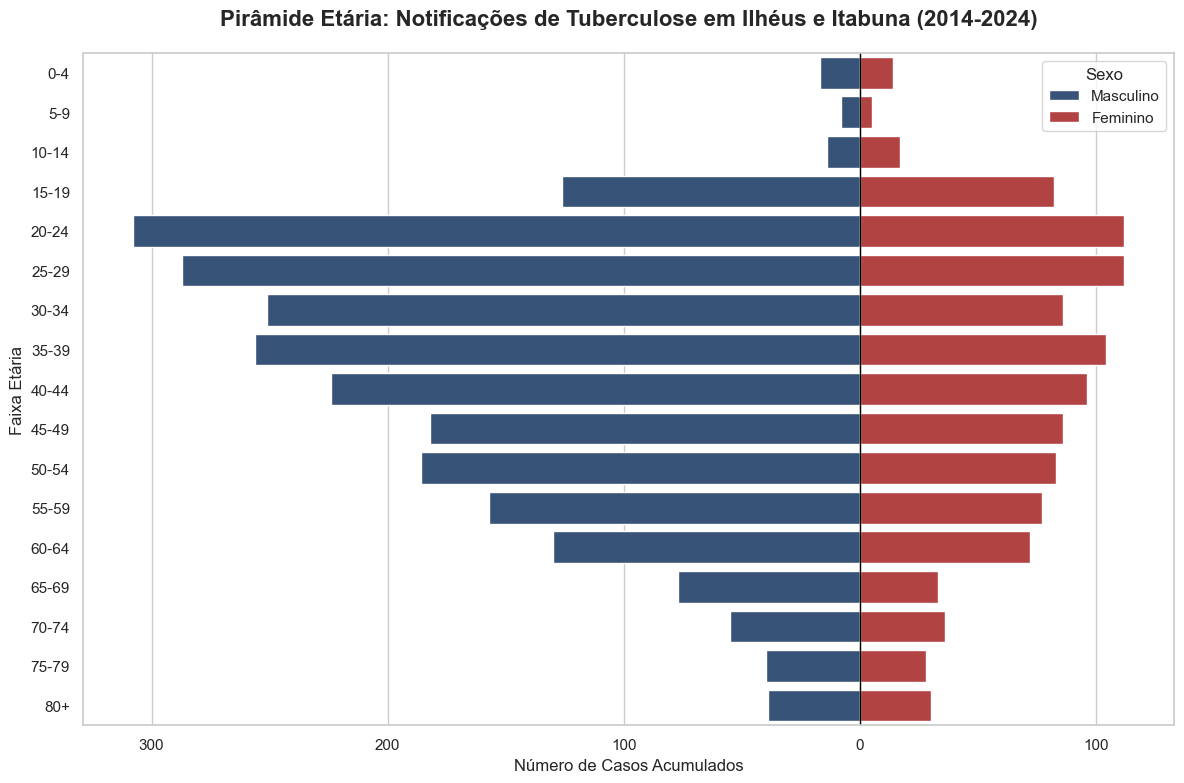

In [8]:
if 'Idade_Codigo' in df.columns:
        df['Idade_Anos'] = df['Idade_Codigo'].apply(descodificar_idade)

#intervalos de 5 em 5 anos
bins = list(range(0, 85, 5)) + [120]
labels = [f'{i}-{i+4}' for i in range(0, 80, 5)] + ['80+']
df['Faixa_Etaria'] = pd.cut(df['Idade_Anos'], bins=bins, labels=labels, right=False)

piramide = df.groupby(['Faixa_Etaria', 'Sexo'], observed=False).size().reset_index(name='Casos')

# Multiplicando os casos masculinos por -1 para as barras crescerem para a esquerda
piramide.loc[piramide['Sexo'] == 'Masculino', 'Casos'] *= -1

#GRÁFICO
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Casos', y='Faixa_Etaria', data=piramide[piramide['Sexo'] == 'Masculino'], 
            color='#2c5282', label='Masculino', ax=ax, errorbar=None)
sns.barplot(x='Casos', y='Faixa_Etaria', data=piramide[piramide['Sexo'] == 'Feminino'], 
            color='#c53030', label='Feminino', ax=ax, errorbar=None)
ticks = ax.get_xticks()
ax.set_xticklabels([int(abs(x)) for x in ticks])
ax.set_title('Pirâmide Etária: Notificações de Tuberculose em Ilhéus e Itabuna (2014-2024)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Número de Casos Acumulados', fontsize=12)
ax.set_ylabel('Faixa Etária', fontsize=12)
ax.axvline(0, color='black', linewidth=1)
plt.legend(title='Sexo', loc='upper right')
plt.tight_layout()

plt.show()



Resultado: Concentração de casos entre pacientes de 20 a 44 anos de idade, com uma grande descrepância entre sexo, sendo homens os mais afetados por tuberculose.





Análise de desfecho clínico (Com destaque para os anos de pandemia da COVID19):



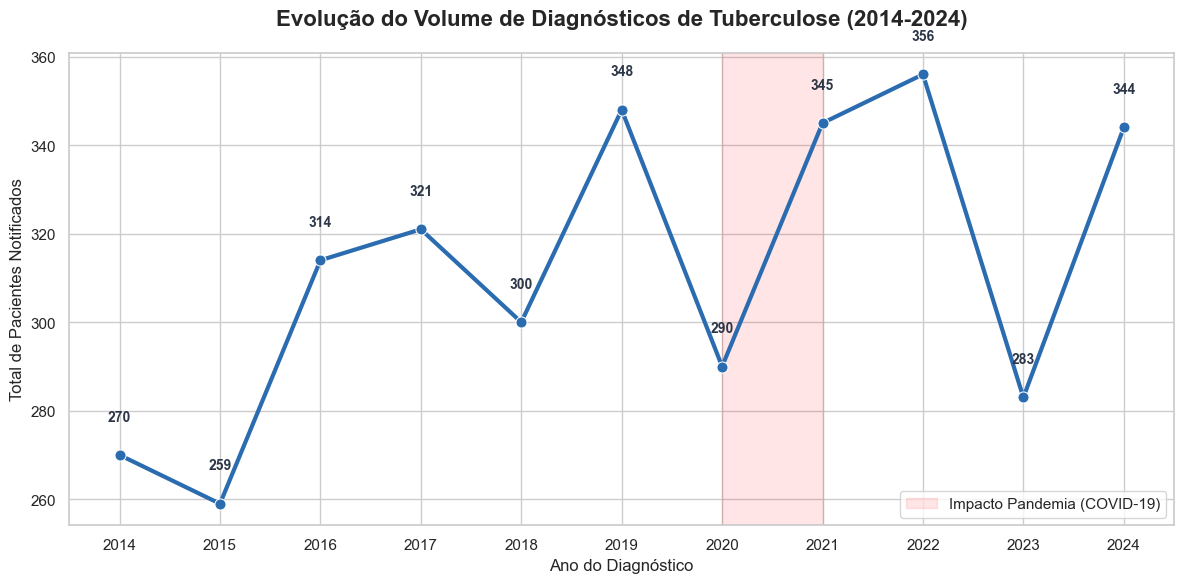

In [9]:
df['Ano_Diagnostico'] = df['Data_Diagnostico'].dt.year
df_temporal = df[(df['Ano_Diagnostico'] >= 2014) & (df['Ano_Diagnostico'] <= 2024)]

evolucao_total = df_temporal.groupby('Ano_Diagnostico').size().reset_index(name='Total_Casos')

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=evolucao_total, x='Ano_Diagnostico', y='Total_Casos', 
             marker='o', markersize=8, linewidth=3, color='#2b6cb0', ax=ax)
ax.axvspan(2020, 2021, color='red', alpha=0.1, label='Impacto Pandemia (COVID-19)')
ax.set_title('Evolução do Volume de Diagnósticos de Tuberculose (2014-2024)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
ax.set_ylabel('Total de Pacientes Notificados', fontsize=12)
ax.set_xticks(range(2014, 2025))
for x, y in zip(evolucao_total['Ano_Diagnostico'], evolucao_total['Total_Casos']):
    ax.text(x, y + (evolucao_total['Total_Casos'].max() * 0.02), f'{y}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2d3748')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



Nessa análise vemos em evidência o período pandêmico, pois mesmo com um pico de tuberculose em 2019, vemos uma brusca queda de agravos em 2020, que não necessariamente significa que a tuberculose diminui, mas que possivelmente postos de saúde e hospitais de Ilhéus e Itabuna estavam focados na COVID-19 e pessoas com sintomas iniciais de tuberculose não foram diagnosticadas, causando o efeito rebote que vemos nos anos de 2021 e 2022.





Análise de evolução de casos dividindo ilhéus e itabuna:

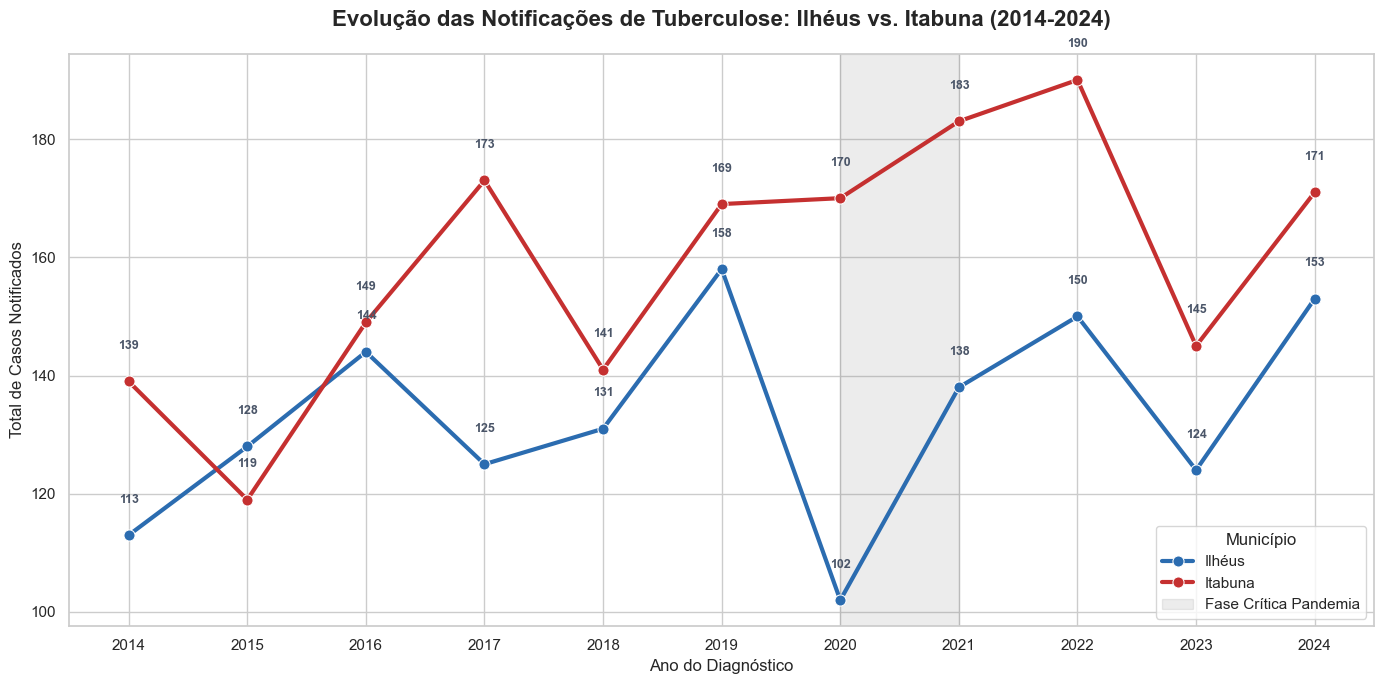

In [18]:
mapa_cidades = {
    291360: 'Ilhéus', '291360': 'Ilhéus', 291360.0: 'Ilhéus',
    291480: 'Itabuna', '291480': 'Itabuna', 291480.0: 'Itabuna'
}

df['Nome_Municipio'] = df['Municipio_Residencia'].replace(mapa_cidades)
df_cidades = df[df['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])].copy()

df_cidades['Ano_Diagnostico'] = df_cidades['Data_Diagnostico'].dt.year
df_temporal = df_cidades[(df_cidades['Ano_Diagnostico'] >= 2014) & (df_cidades['Ano_Diagnostico'] <= 2024)].copy()
evolucao_municipio = df_temporal.groupby(['Ano_Diagnostico', 'Nome_Municipio']).size().reset_index(name='Casos')

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=evolucao_municipio, x='Ano_Diagnostico', y='Casos', 
             hue='Nome_Municipio', palette=['#2b6cb0', '#c53030'], 
             marker='o', markersize=8, linewidth=3, ax=ax)
ax.axvspan(2020, 2021, color='gray', alpha=0.15, label='Fase Crítica Pandemia')
ax.set_title('Evolução das Notificações de Tuberculose: Ilhéus vs. Itabuna (2014-2024)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
ax.set_ylabel('Total de Casos Notificados', fontsize=12)
ax.set_xticks(range(2014, 2025))

for line in range(evolucao_municipio.shape[0]):
    ax.text(evolucao_municipio['Ano_Diagnostico'].iloc[line], 
            evolucao_municipio['Casos'].iloc[line] + 5, 
            evolucao_municipio['Casos'].iloc[line], 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#4a5568')

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Município', loc='lower right')
plt.tight_layout()

plt.show()

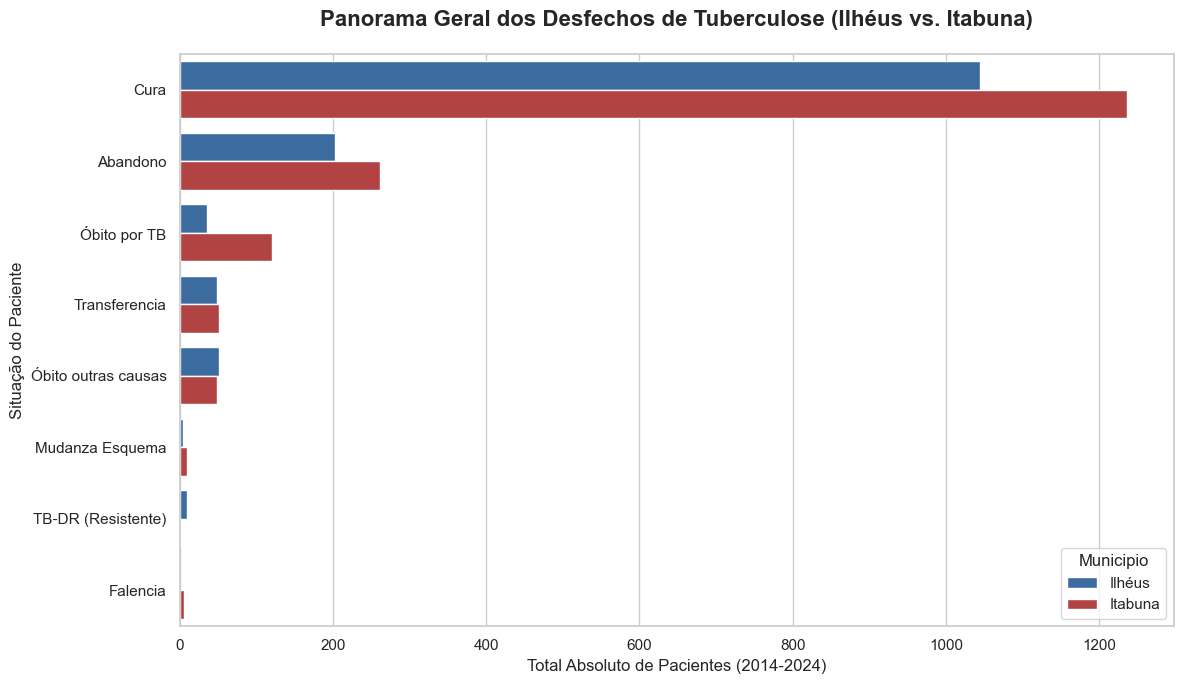

In [23]:
df['Nome_Municipio'] = df['Municipio_Residencia'].map(mapa_cidades)
df_analise = df[df['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])].copy()
mapa_desfechos = {
    1.0: 'Cura',
    2.0: 'Abandono',
    3.0: 'Óbito por TB',
    4.0: 'Óbito outras causas',
    5.0: 'Transferencia',
    6.0: 'Mudanza Diagnóstico',
    7.0: 'TB-DR (Resistente)',
    8.0: 'Mudanza Esquema',
    9.0: 'Falencia'
}

df_analise['Desfecho_Clinico'] = df_analise['Situacao_Encerramento_Final'].map(mapa_desfechos)
df_analise = df_analise.dropna(subset=['Desfecho_Clinico'])
fig, ax = plt.subplots(figsize=(12, 7))
sns.countplot(data=df_analise, 
              y='Desfecho_Clinico', 
              hue='Nome_Municipio', 
              palette=['#2b6cb0', '#c53030'],
              order=df_analise['Desfecho_Clinico'].value_counts().index)
ax.set_title('Panorama Geral dos Desfechos de Tuberculose (Ilhéus vs. Itabuna)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Absoluto de Pacientes (2014-2024)', fontsize=12)
ax.set_ylabel('Situação do Paciente', fontsize=12)
plt.legend(title='Municipio', loc='lower right')
plt.tight_layout()

plt.show()

/tmp/ipykernel_37310/1725606032.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(data=evolucao,


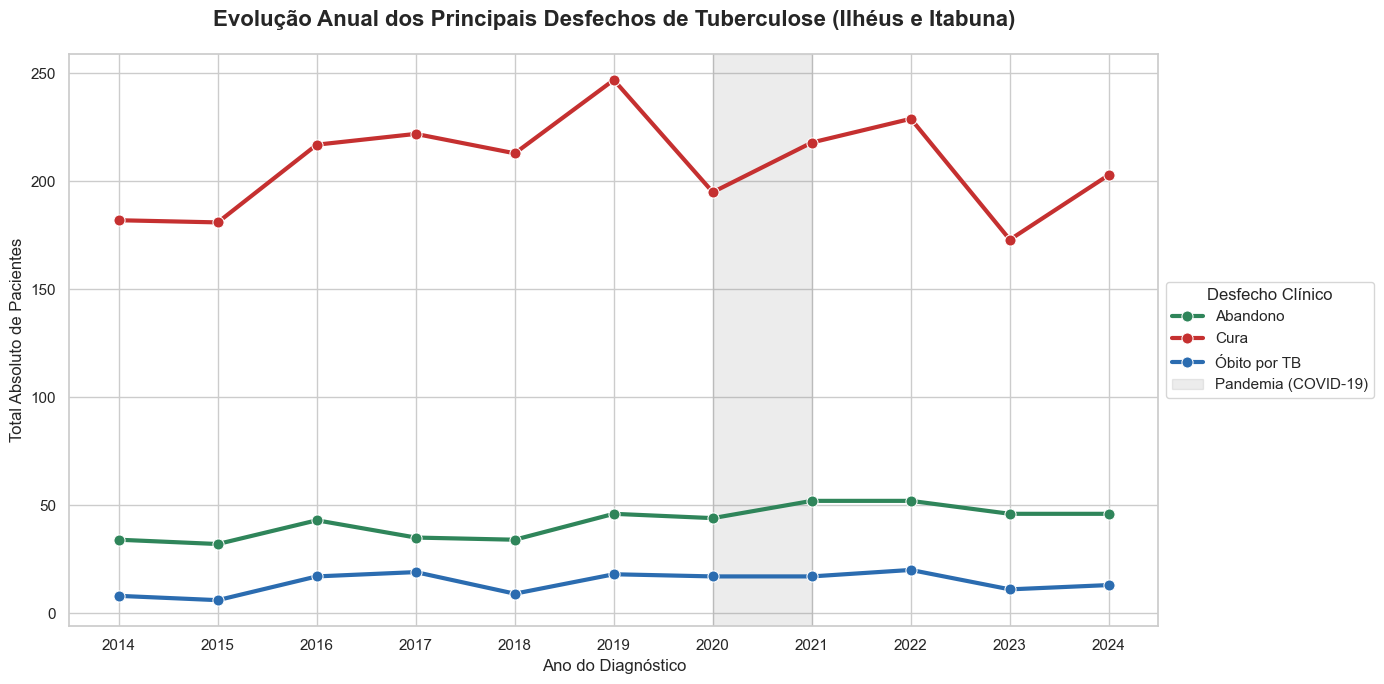

In [20]:
df_analise = df.copy()
df_analise['Nome_Municipio'] = df_analise['Municipio_Residencia'].map(mapa_cidades)
df_analise = df_analise[df_analise['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]
df_analise['Desfecho_Clinico'] = df_analise['Situacao_Encerramento_Final'].map(mapa_desfechos)
df_analise = df_analise.dropna(subset=['Desfecho_Clinico'])
df_analise['Data_Diagnostico'] = pd.to_datetime(df_analise['Data_Diagnostico'], errors='coerce')
df_analise['Ano_Diagnostico'] = df_analise['Data_Diagnostico'].dt.year
df_analise = df_analise[(df_analise['Ano_Diagnostico'] >= 2014) & (df_analise['Ano_Diagnostico'] <= 2024)]
desfechos_alvo = ['Cura', 'Abandono', 'Óbito por TB', 'Transferência']
df_linhas = df_analise[df_analise['Desfecho_Clinico'].isin(desfechos_alvo)]
evolucao = df_linhas.groupby(['Ano_Diagnostico', 'Desfecho_Clinico']).size().reset_index(name='Casos')

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=evolucao, 
             x='Ano_Diagnostico', 
             y='Casos', 
             hue='Desfecho_Clinico', 
             palette=['#2f855a', '#c53030', '#2b6cb0', '#805ad5'],
             marker='o', markersize=8, linewidth=3, ax=ax)

# Destacando o período da pandemia
ax.axvspan(2020, 2021, color='gray', alpha=0.15, label='Pandemia (COVID-19)')
ax.set_title('Evolução Anual dos Principais Desfechos de Tuberculose (Ilhéus e Itabuna)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
ax.set_ylabel('Total Absoluto de Pacientes', fontsize=12)
anos_unicos = sorted(evolucao['Ano_Diagnostico'].unique())
ax.set_xticks(anos_unicos)
ax.set_xticklabels([int(ano) for ano in anos_unicos])
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Desfecho Clínico', 
           loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

plt.show()

O número absoluto de abandonos se manteve estável mesmo durante as flutuações da pandemia, isso indica que o núcleo de acompanhamento da vigilância epidemiológica das duas cidades conseguiu se manter eficaz e não perdeu totalmente os pacientes de tuberculose, mesmo no auge do caos na saúde pública.

Tuberculose raramente anda sozinha. O SINAN tem colunas para HIV/AIDS, Alcoolismo e Diabetes. Vamos analisar como essas doenças preexistentes se distribuiem entre os pacientes de tuberculose.

/tmp/ipykernel_37310/4031520686.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comorbidades,


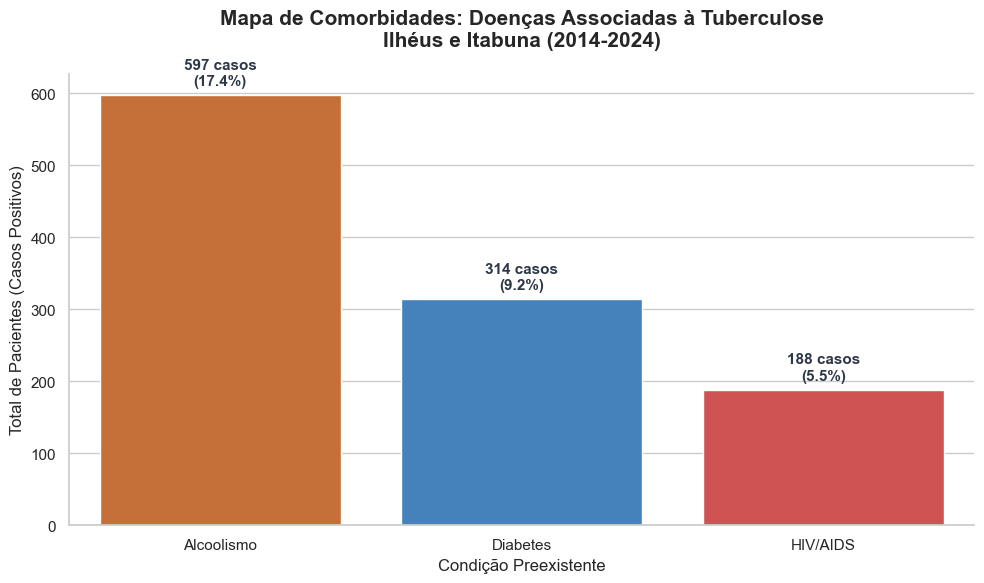

In [22]:
dicionario_comorbidades = {
    'Agravo_Alcoolismo': 'Alcoolismo',
    'Agravo_Diabetes': 'Diabetes',
    'Agravo_AIDS': 'HIV/AIDS'
}

dados_comorbidade = []
total_pacientes = len(df)
for coluna_original, nome_doenca in dicionario_comorbidades.items():
    if coluna_original in df.columns:
        casos_positivos = (df[coluna_original] == 1.0).sum()
        taxa_percentual = (casos_positivos / total_pacientes) * 100
        dados_comorbidade.append({
            'Comorbidade': nome_doenca,
            'Total Absoluto': casos_positivos,
            'Percentual (%)': taxa_percentual
        })
df_comorbidades = pd.DataFrame(dados_comorbidade).sort_values(by='Total Absoluto', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_comorbidades, 
            x='Comorbidade', 
            y='Total Absoluto', 
            palette=['#dd6b20', '#3182ce', '#e53e3e'],
            ax=ax)
ax.set_title('Mapa de Comorbidades: Doenças Associadas à Tuberculose\nIlhéus e Itabuna (2014-2024)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Condição Preexistente', fontsize=12)
ax.set_ylabel('Total de Pacientes (Casos Positivos)', fontsize=12)
for i in range(df_comorbidades.shape[0]):
    valor_absoluto = df_comorbidades['Total Absoluto'].iloc[i]
    percentual = df_comorbidades['Percentual (%)'].iloc[i]
    texto_barra = f"{valor_absoluto} casos\n({percentual:.1f}%)"
    ax.text(i, valor_absoluto + 10, texto_barra, 
            color='#2d3748', ha="center", va="bottom", 
            fontsize=11, fontweight='bold')


sns.despine()
plt.tight_layout()
plt.show()

Pacientes que sofrem de alcoolismo, por ter seus sistema imunológico afetado pelo grande consumo de álcool, se torna indefeso à bactéria da tuberculose, aumentando em grande nível as chances de infecção, principalmente por questões sociais em que esses indivíduos se encontram como locais de frequente aglomeração e/ou situação de rua

Fazer relação entre Alcoolismo e abandono, pois o tratamento dura 6 meses e não pode consumir álcool nesse período

Resultados parciais da análise:

* Perfil Demográfico (Vulnerabilidade Ativa): A análise da pirâmide etária demonstrou uma clara prevalência da doença em homens adultos (particularmente na faixa dos 20 aos 44 anos). Este padrão sugere que a população economicamente ativa e com maior mobilidade urbana é a mais exposta e afetada na região.

* O Efeito Pandemia (Impacto da COVID-19): A série temporal da década revelou uma anomalia grave: uma queda abrupta nas notificações durante 2020. Isto não representou uma diminuição da doença, mas sim um "apagão de diagnósticos" devido à sobrecarga do sistema de saúde pela pandemia. O resultado foi efeito de rebote em 2021 e 2022, indicando que os pacientes não diagnosticados anteriormente regressaram ao sistema.

* Comorbilidades: Ao mapear as doenças preexistentes, descobrimos que o Alcoolismo (17,4%) é a comorbilidade mais frequente entre os pacientes da região, ultrapassando até mesmo o HIV/AIDS e a Diabetes. O paciente alcoolista tem, estatisticamente, uma probabilidade muito maior de Abandonar o Tratamento, o que favorece a criação de bactérias super-resistentes.

* Desfecho Clínico:
Apesar da crise sanitária entre 2020 e 2021, a análise da evolução dos desfechos revelou que as taxas absolutas de Abandono e Óbito mantiveram-se relativamente estáveis. Isto indica que a vigilância epidemiológica e os núcleos de acompanhamento de Ilhéus e Itabuna conseguiram demonstrar resiliência, não perdendo totalmente o rastro aos pacientes mais vulneráveis durante o pico do caos hospitalar.
